## Computational Astrobiology – Project Dataset Generation

### Preamble – Importing & Reading

In [1]:
%%capture
%pip -q install ldtk

In [2]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']

from IPython.display import clear_output

import json
import yaml

import copy
import os
import subprocess
import sys
import time

import tempfile
import h5py

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import h5py

from ldtk import LDPSetCreator, BoxcarFilter

plato_filter = BoxcarFilter('plato', 400, 1000)

orig_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
try:
    dummy_sc = LDPSetCreator(teff=(5778, 1), logg=(4.438, 0.01), z=(0, 0.1), filters=[plato_filter])
finally:
    sys.stdout.close()
    sys.stdout = orig_stdout

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['olivedrab', 'steelblue', 'firebrick', 'goldenrod'])
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.limits'] = (0, 0)
plt.rcParams['figure.figsize'] = [6,4]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

template_file = 'PSLS/examples/psls.yaml'

with open(template_file, 'r') as file:
    config_dict = yaml.safe_load(file)
    print(json.dumps(config_dict, indent=4, sort_keys=False))

{
    "Observation": {
        "QuarterDuration": [
            90.0,
            90.0,
            90.0
        ],
        "MasterSeed": 1704040900,
        "Gaps": {
            "Enable": 1,
            "Seed": -1,
            "InterQuarterGapDuration": 3.0,
            "RandomGapDuration": 0.0,
            "RandomGapTimeFraction": 0.5,
            "RandomGapStep": 0.0,
            "PeriodicGapCadence": 5.0,
            "PeriodicGapDuration": 20.0,
            "PeriodicGapJitter": 2.0,
            "PeriodicGapStep": 0.0
        }
    },
    "Instrument": {
        "Sampling": 25.0,
        "IntegrationTime": 21.0,
        "GroupID": [
            1,
            2,
            3,
            4
        ],
        "NCamera": 6,
        "TimeShift": 6.25,
        "RandomNoise": {
            "Enable": 1,
            "Type": "PLATO_SIMU",
            "NSR": 73.0
        },
        "Systematics": {
            "Enable": 1,
            "Table": "systematics/PLATO_systematics_BOL_V2.npy",
  

### Template Dictionary

In [3]:
psls_template = {
    'Observation': {
        'QuarterDuration': [90.0] * 16,     # days
        'MasterSeed': 0,
        'Gaps': {
            'Enable': 1,
            'Seed': -1,
            'InterQuarterGapDuration': 3.0, # days
            'RandomGapDuration': 20.0,      # minutes
            'RandomGapTimeFraction': 0.05,
            'RandomGapStep': 0.0,
            'PeriodicGapCadence': 5.0,      # days
            'PeriodicGapDuration': 20.0,    # minutes
            'PeriodicGapJitter': 2.0,
            'PeriodicGapStep': 0.0
        }
    },
    'Instrument': {
        'Sampling': 300.0,                 # seconds (default: 25.0)
        'IntegrationTime': 252.0,          # seconds (default: 21.0)
        'GroupID': [1, 2, 3, 4],
        'NCamera': 6,
        'TimeShift': 6.25,                 # seconds
        'RandomNoise': {
            'Enable': 1,
            'Type': 'PLATO_SIMU',
            'NSR': 73.0
        },
        'Systematics': {
            'Enable': 1,
            'Table': 'systematics/PLATO_systematics_BOL_V2.npy',
            'Version': 2,
            'DriftLevel': 'any',
            'Seed': -1
        }
    },
    'Star': {
        'Mag': 10.0,
        'ID': 0,
        'ModelType': 'grid',
        'ModelDir': 'models/',
        'ModelName': 'grid.hdf5',
        'ES': 'ms',
        'Teff': 5778.0,                   # not UP
        'Logg': 4.438,                    # not UP
        'SurfaceRotationPeriod': 0.0,     # not UP
        'CoreRotationFreq': 0.0,          # only UP
        'Inclination': 0.0
    },
    'Oscillations': {
        'Enable': 1,
        'numax': 180.0,                    # only UP
        'delta_nu': 14.0,                  # only UP
        'DPI': 81.0,                       # only UP
        'q': 0.15,                         # only UP
        'SurfaceEffects': 1,               # not UP
        'Seed': -1
    },
    'Activity': {
        'Enable': 1,
        'Sigma': 40.0,
        'Tau': 0.2,
        'Seed': -1,
        'Spot': {
            'Enable': 0,
            'dOmega': 0.0,
            'MuStar': 0.59,
            'MuSpot': 0.78,
            'Radius': [2.5, 2.5, 2.5],
            'Latitude': [0.0, 20.0, 40.0],
            'Longitude': [0.0, 0.0, 0.0],
            'Lifetime': [10, 30, 50],
            'TimeMax': [-1, -1, -1],
            'Contrast': [0.7, 0.8, 0.6],
            'Modulation': 0.0,
            'Seed': -1
        },
        'Flare': {
            'Enable': 0,
            'MeanPeriod': 2,
            'Amplitude': 2500.0,
            'UpDown': 0.1,
            'MeanDuration': -1,
            'DurationDispersion': -1,
            'Seed': -1
        }
    },
    'Granulation': {
        'Enable': 1,
        'Type': 1,
        'Seed': -1
    },
    'Transit': {
        'Enable': 1,
        'PlanetRadius': 0.5,
        'OrbitalPeriod': 10.0,
        'PlanetSemiMajorAxis': 1.0,
        'OrbitalAngle': 0.0,
        'LimbDarkeningCoefficients': [0.25, 0.75]
    },
    'External': {
        'Enable': 0,
        'FilePath': 'examples/external_example.txt'
    }
}

### Auxiliary Functions

In [4]:
def initialize(file_name, total_sims, date_string):
    with h5py.File(file_name, 'x') as f:
        f.attrs['description'] = f'Batch Simulation Results ({total_sims} Runs)'
        f.attrs['date_created'] = date_string
        f.attrs['user'] = 'Fritz Ali Agildere'

def run(temp_file):
    %cd -q PSLS
    !echo '' | ./psls.py -o data {temp_file.name} > /dev/null 2>&1
    %cd -q ..

def save(i, file_name, group_name, temp_file):
    with h5py.File(file_name, 'a') as f:
        run = f.create_group(group_name)
        
        with open(temp_file.name, 'r') as cfg:
            run.attrs['config_used'] = cfg.read()

        with open(f'PSLS/data/{i:010d}.txt', 'r') as txt:
            content = txt.read()
            dt = h5py.string_dtype(encoding='utf-8')
            run.create_dataset('txt', data=content, dtype=dt)
            
        dat = f[group_name].create_group('dat')
        time_s, flux_var_ppm, flag = np.genfromtxt(f'PSLS/data/{i:010d}.dat', unpack=True, skip_header=5)
        
        dat.create_dataset('time_s', data=time_s, compression='gzip', shuffle=True)
        dat.create_dataset('flux_var_ppm', data=flux_var_ppm, compression='gzip', shuffle=True)
        dat.create_dataset('flag', data=flag, compression='gzip', shuffle=True)
        
        modes = f[group_name].create_group('modes')
        n, l, m, nu, gamma, h, I_Imax, dnu, split = np.genfromtxt(f'PSLS/data/{i:010d}.modes', unpack=True, skip_header=1)
        
        modes.create_dataset('n', data=n, compression='gzip', shuffle=True)
        modes.create_dataset('l', data=l, compression='gzip', shuffle=True)
        modes.create_dataset('m', data=m, compression='gzip', shuffle=True)
        modes.create_dataset('nu', data=nu, compression='gzip', shuffle=True)
        modes.create_dataset('gamma', data=gamma, compression='gzip', shuffle=True)
        modes.create_dataset('h', data=h, compression='gzip', shuffle=True)
        modes.create_dataset('I_Imax', data=I_Imax, compression='gzip', shuffle=True)
        modes.create_dataset('dnu', data=dnu, compression='gzip', shuffle=True)
        modes.create_dataset('split', data=split, compression='gzip', shuffle=True)

def clean(i):
    txt = f'PSLS/data/{i:010d}.txt'
    dat = f'PSLS/data/{i:010d}.dat'
    modes = f'PSLS/data/{i:010d}.modes'
    
    %rm {txt}
    %rm {dat}
    %rm {modes}

### Parameter Sampling

In [5]:
teff_sun = 5.778e3
m_sun = 1.98919e33
r_sun = 6.9599e10
lum_sun = 3.828e33
logg_sun = 4.438e0
rot_sun = 2.6e1
sig_sun = 3e1

def sample(i, config_dict, planet_setting, use_case, rng):
    config_dict['Observation']['MasterSeed'] = i
    config_dict['Star']['ID'] = i
    config_dict['Star']['Mag'] = float(rng.uniform(9.0, 13.0))

    metal = float(rng.normal(-0.1, 0.2))
    if use_case == 'training':
        mass = float(rng.uniform(0.91, 1.19))
    elif use_case == 'science':
        mass = float(rng.uniform(1.2**(-1.35), 0.9**(-1.35))**(-1/1.35))

    radius = float(mass**0.8 * (1 + 0.12 * metal))
    teff = float(teff_sun * mass**0.5 * (1 - 0.06 * metal))
    logg = float(logg_sun + np.log10(mass) - 2 * np.log10(radius))
    lum = float(lum_sun * radius**2 * (teff / teff_sun)**4)
    
    config_dict['Star']['Teff'] = teff
    config_dict['Star']['Logg'] = logg

    if use_case == 'training':
        rotType = rng.choice(['fast', 'slow'], p=[0.5, 0.5])
    elif use_case == 'science':
        rotType = rng.choice(['fast', 'slow'], p=[0.05, 0.95])

    if rotType == 'slow':
        rot_period = rng.lognormal(np.log(25), 0.2)
    elif rotType == 'fast':
        rot_period = rng.lognormal(np.log(4), 0.4)

    config_dict['Star']['SurfaceRotationPeriod'] = rot_period

    config_dict['Activity']['Sigma'] = rng.normal(sig_sun, sig_sun / 6) * (rot_sun / rot_period)**2
    config_dict['Activity']['Tau'] = rot_period / 2 + rng.normal(0, rot_period / 20)
    
    tau_convect = 14 * mass**(-2.5)
    ratio = rot_period / tau_convect
    sigmoid = 1 / (1 + np.exp(40 * (ratio - 0.12)))

    config_dict['Activity']['Spot']['Enable'] = int(rng.uniform(0, 1) < sigmoid)
    config_dict['Activity']['Flare']['Enable'] = int(rng.uniform(0, 1) < sigmoid)
    
    if planet_setting == 'on':
        config_dict['Transit']['Enable'] = 1

        orig_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')
        try:
            sc = LDPSetCreator(teff=(teff, 50), logg=(logg, 0.05), z=(metal, 0.1), filters=[plato_filter])
            ps = sc.create_profiles()
            u1, u2 = ps.coeffs_qd()
        finally:
            sys.stdout.close()
            sys.stdout = orig_stdout

        config_dict['Transit']['LimbDarkeningCoefficients'] = [float(u1[0,0]), float(u2[0,0])]
        
    elif planet_setting == 'off':
        config_dict['Transit']['Enable'] = 0

    

### Simulation Loop

In [6]:
def simulate(total_sims = 630, initial_state = 0, seed = 123, title = 'none', usage = 'science', planet = 'on'):
    
    start_batch = time.time()

    id_str = time.strftime('%Y%m%d%H%M%S', time.gmtime(start_batch))
    attr_str = time.strftime('%d.%m.%Y, %H:%M:%S', time.gmtime(start_batch))

    file_name = f'PSLS/data/{id_str}.hdf5'

    if title != 'none':
        initialize(file_name, total_sims, title)
    else:
        initialize(file_name, total_sims, attr_str)

    initial_status = f'│ progress |{'░' * 50}| 0% [running 1/{total_sims}] (00:00:00/--:--:--)          '
    
    print(f'{initial_status}')
    
    i = initial_state
    j = 0
    k = h5py.File(file_name, 'r')
    while len(k) < total_sims + initial_state:
        k.close()

        if i != 0:
            perc = i / (total_sims + j) * 100
            bar = '█' * int(perc // 2) + '░' * (50 - int(perc // 2))
            status = f'│ progress |{bar}| {perc:.0f}% [running {i+1}/{total_sims + j}] ({elapsed_str}/{estimated_str})          '
    
            clear_output(wait=True)
            print(f'{status}')

        config = copy.deepcopy(psls_template)

        sys.stdout.write(f'└── initializing simulation {i + 1}          ')
        sys.stdout.flush()
        sys.stdout.write(f'\r└─┬ initializing simulation {i + 1}          \n')
        sys.stdout.write(f'  └── sampling parameters [active]          ')
        sys.stdout.flush()
        
        sample(i, config, planet, usage, np.random.default_rng(i + seed))
        
        with tempfile.NamedTemporaryFile(suffix='.yaml', dir='PSLS', mode='w', delete=True) as tf:
            yaml.dump(config, tf, default_flow_style=False, sort_keys=False)
            tf.flush()
            
            sys.stdout.write(f'\r  ├── sampling parameters [done]          \n')
            sys.stdout.write(f'  └── generating lightcurve [active]          ')
            sys.stdout.flush()
            
            run(tf)

            if os.path.isfile(f'PSLS/data/{i:010d}.txt'):
                sys.stdout.write(f'\r  ├── generating lightcurve [done]          \n')
                sys.stdout.write(f'  └── saving dataframe [active]          ')
                sys.stdout.flush()

                group_name = f'run_{i + 1:05d}'
                
                save(i, file_name, group_name, tf)
                clean(i)
            else:
                j += 1

        current_run = time.time()
        
        elapsed_batch = current_run - start_batch
        
        average_time = elapsed_batch / (i + 1)
        
        estimated_batch = elapsed_batch + (total_sims + j - (i + 1)) * average_time
    
        elapsed_str = time.strftime('%H:%M:%S', time.gmtime(elapsed_batch))
        estimated_str = time.strftime('%H:%M:%S', time.gmtime(estimated_batch))
    
        i += 1
        k = h5py.File(file_name, 'r')

    final_status = f'│ progress |{'█' * 50}| 100% [finished {i}/{total_sims + j}] ({elapsed_str}/{estimated_str})          '

    clear_output(wait=True)
    print(f'{final_status}')

In [7]:
simulate(2)

│ progress |██████████████████████████████████████████████████| 100% [finished 3/3] (00:00:49/00:00:49)          


In [9]:
with h5py.File('PSLS/data/20260508014320.hdf5', 'r') as f:
    print(len(f.keys()))
    print(f.keys())
    print(f['run_00003'].keys())
    print(f['run_00003/dat'].keys())
    print(f['run_00003/modes'].keys())
    print(f['run_00003/txt'][()].decode('utf-8'))

2
<KeysViewHDF5 ['run_00001', 'run_00003']>
<KeysViewHDF5 ['dat', 'modes', 'txt']>
<KeysViewHDF5 ['flag', 'flux_var_ppm', 'time_s']>
<KeysViewHDF5 ['I_Imax', 'dnu', 'gamma', 'h', 'l', 'm', 'n', 'nu', 'split']>
StarID = 0000000002
Master_seed = 2
Version =    1.90
# star parameters:
 teff = 6167.192007 ,logg = 4.470359
 mass = 1.06365,  teff = 6167.19,  radius = 0.993061,  logg = 4.47055,  lum = 1.28635,  age = 30.9554
# observations parameters:
 magnitude = 12.407,  duration = 1440,  sampling = 300,  frequency_resolution = 0.00803755,  nyquist = 1666.67,  white_noise = -60,  time_steps_number = 414720,  bolometric_coefficient = 1.03132
# oscillation parameters:
 numax = 3183.85,  deltanu = 140.692,  Amax = 3.25404,  Hmax = 2.7306,  Gammamax = 2.46871,  width_envelop = 798.255,  se_a = -0.00682208,  se_b = 4.17635
# granulation parameters:
 h1 = 0.703435,  tau1 = 0.000200862,  alpha1 = 4,  h2 = 0.215205,  tau2 = 5.62449e-05,  alpha2 = 4,  taue = 0.000177096
# activity parameters:
 sigma

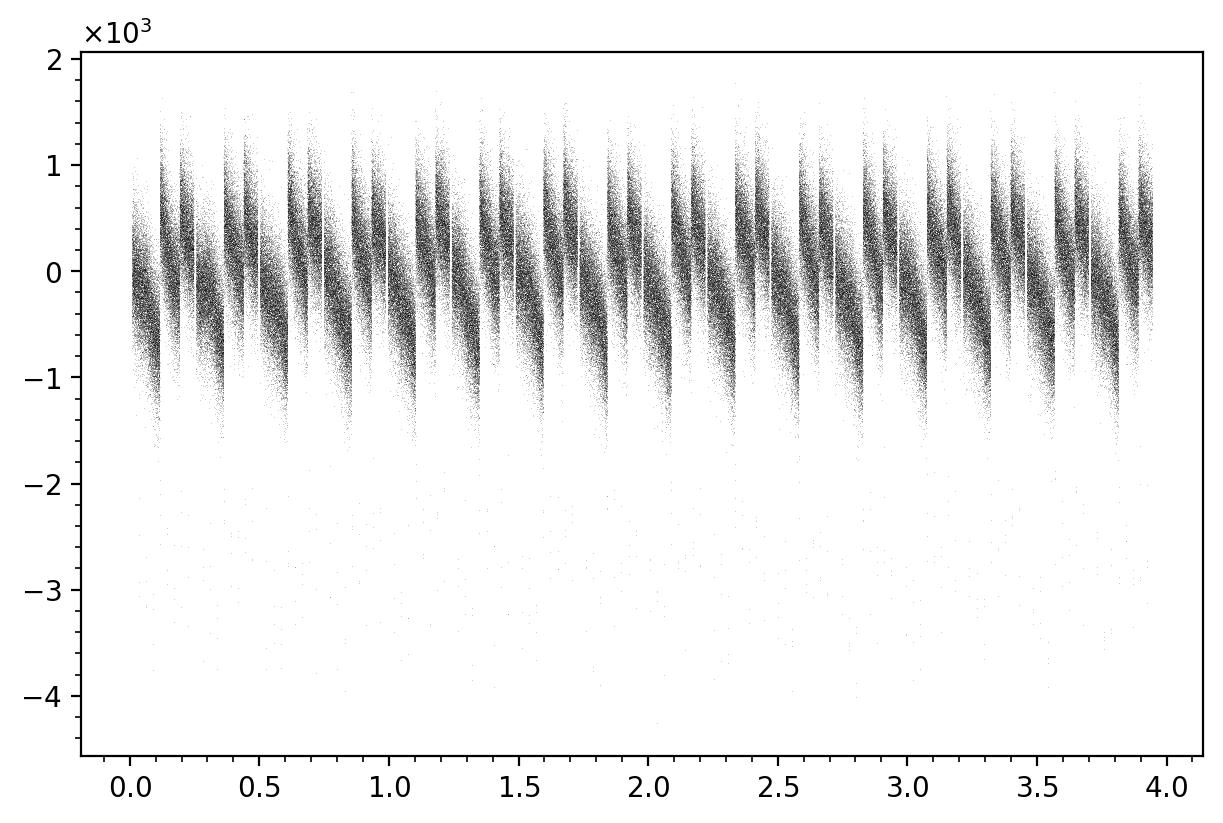

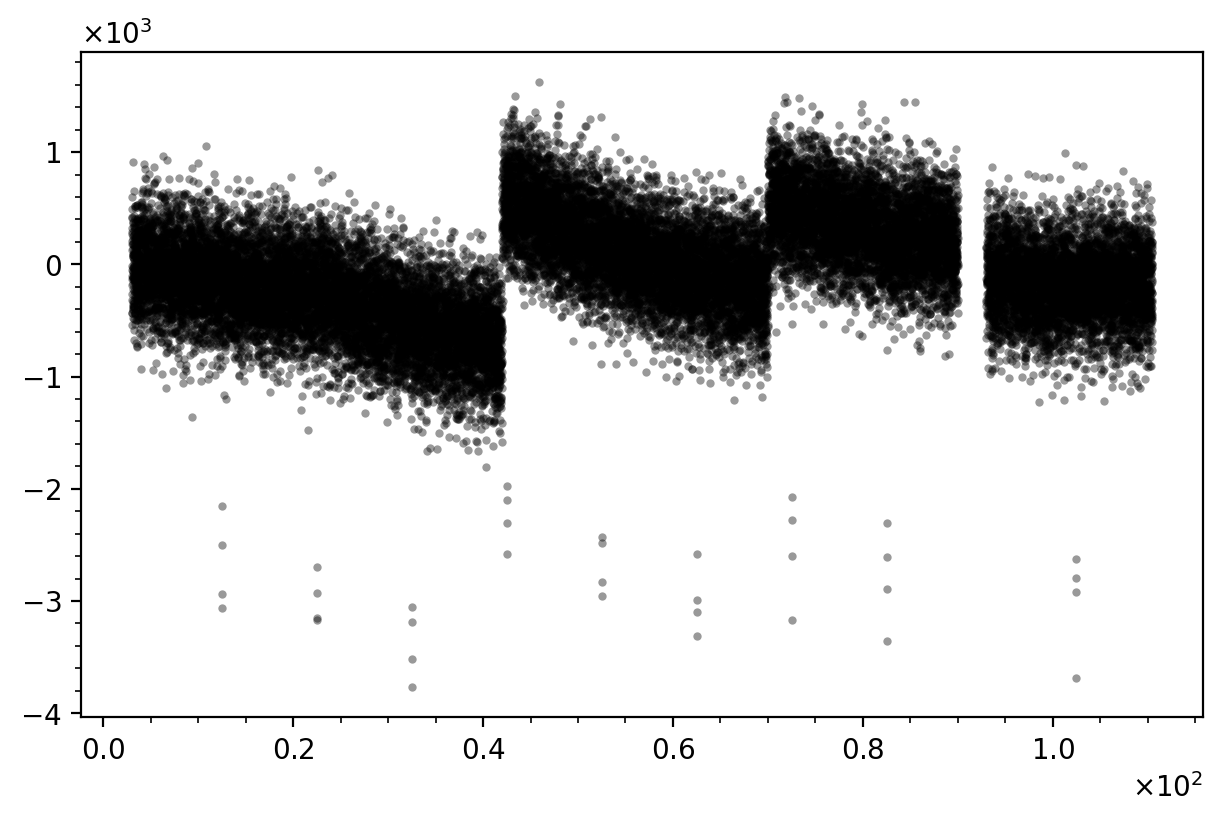

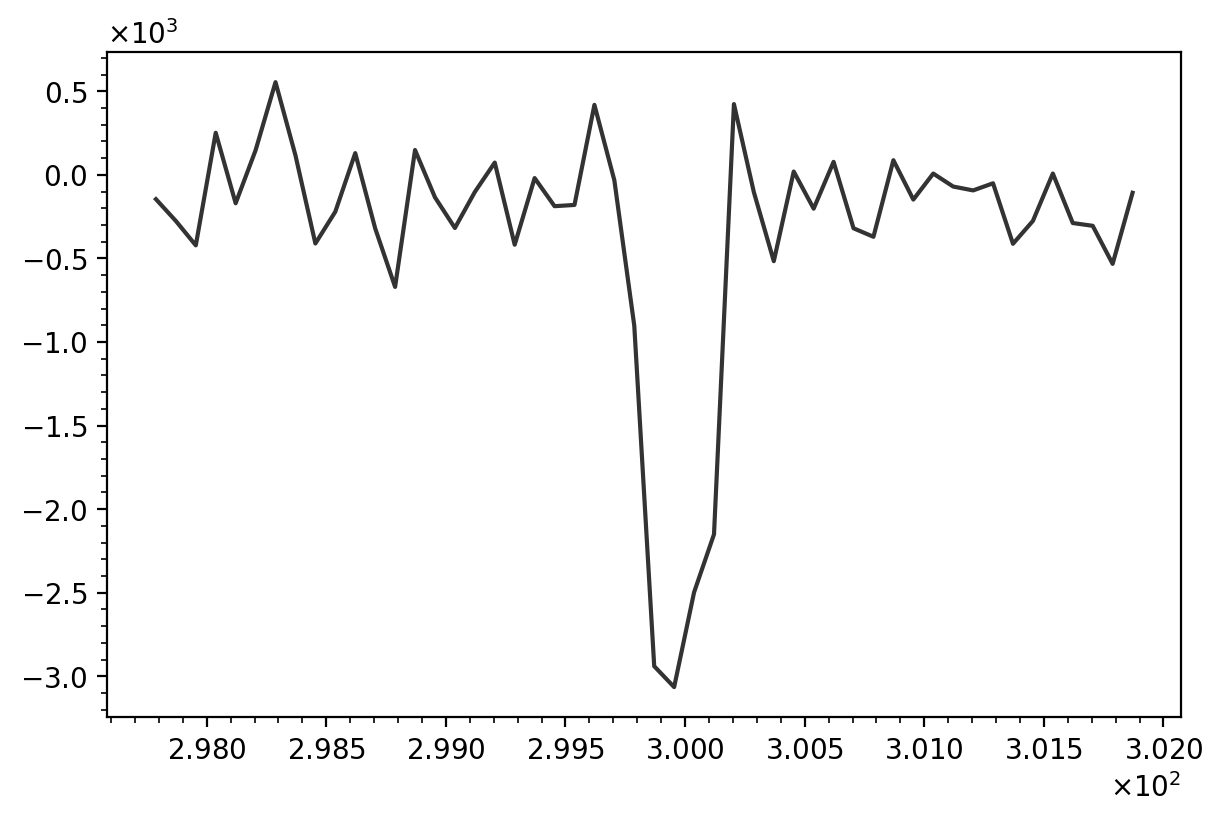

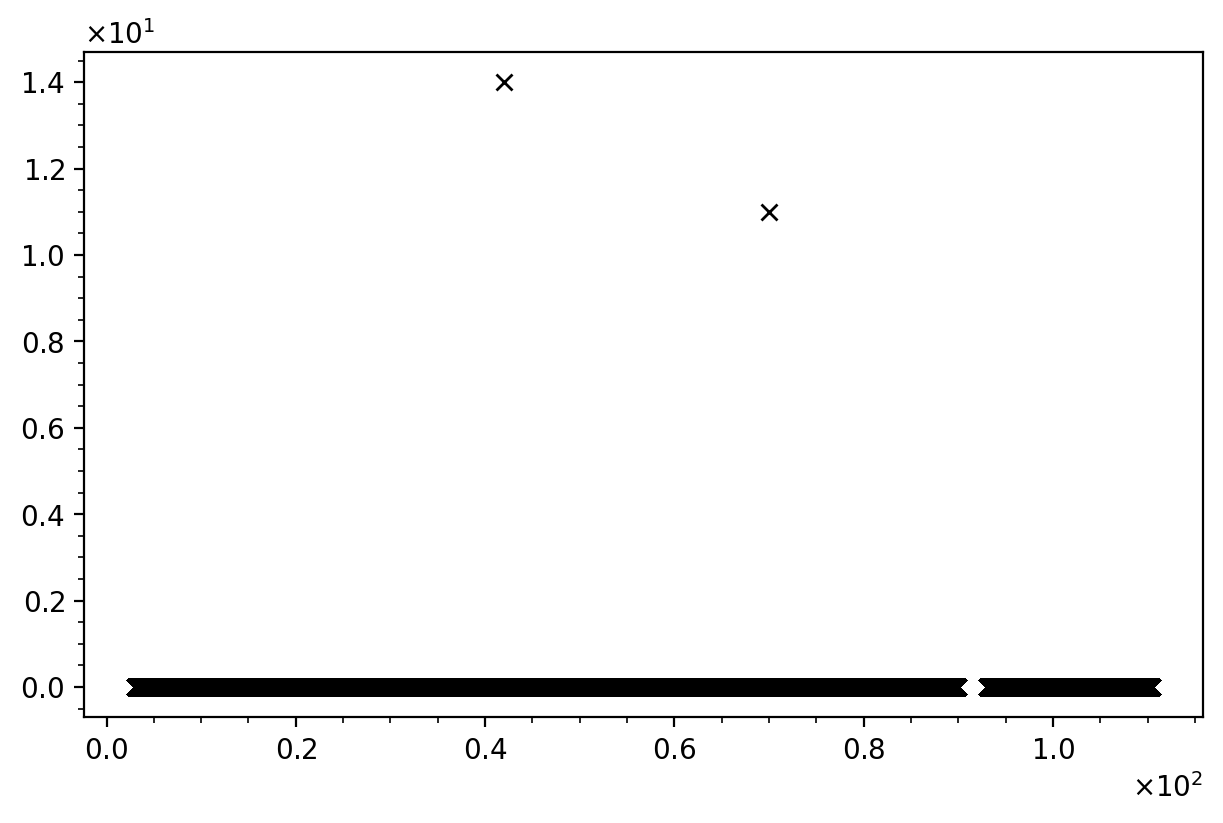

In [10]:
with h5py.File('PSLS/data/20260508014320.hdf5', 'r') as f:
    x = f['run_00003/dat/time_s'][:] / (3600 * 24 * 365)
    y = f['run_00003/dat/flux_var_ppm'][:]
    z = f['run_00003/dat/flag'][:]
    plt.plot(x, y, 'k,', alpha=0.2)
    plt.show()
    plt.close()
    plt.plot(x[:30000] * (365), y[:30000], 'k.', mec='none', alpha=0.4)
    plt.show()
    plt.close()
    low = 2700
    up = 2750
    plt.plot(x[low:up] * (24 * 365), y[low:up], 'k-', mec='none', alpha=0.8)
    plt.show()
    plt.close()
    plt.plot(x[:30000] * (365), z[:30000], 'kx', alpha=1)
    plt.show()
    plt.close()